<a href="https://colab.research.google.com/github/paru725/NorthStar-Logistics-Analytics/blob/main/Section%203_SQL_in_R_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PARVATHI RAMADAS_32146910_SECTION 1: SQL in R & Analytics**

---






**SECTION 1: SQL in R & Analytics**

---



**1: GitHub Connection and Data Loading**

In [1]:
github_url <- "https://raw.githubusercontent.com/paru725/NorthStar-Logistics-Analytics/refs/heads/main/"

# Load core libraries
install.packages(c("sqldf", "ggplot2", "dplyr", "readr", "corrplot"))
library(sqldf)
library(ggplot2)
library(dplyr)
library(readr)
library(corrplot)

# Import all analytical files
app_events <- read_csv(paste0(github_url, "app_events.csv"), show_col_types = FALSE)
complaints <- read_csv(paste0(github_url, "complaints.csv"), show_col_types = FALSE)
customers  <- read_csv(paste0(github_url, "customers.csv"), show_col_types = FALSE)
deliveries <- read_csv(paste0(github_url, "deliveries.csv"), show_col_types = FALSE)
drivers    <- read_csv(paste0(github_url, "drivers.csv"), show_col_types = FALSE)
hubs       <- read_csv(paste0(github_url, "hubs.csv"), show_col_types = FALSE)
incidents  <- read_csv(paste0(github_url, "incidents.csv"), show_col_types = FALSE)
orders     <- read_csv(paste0(github_url, "orders.csv"), show_col_types = FALSE)
vehicles   <- read_csv(paste0(github_url, "vehicles.csv"), show_col_types = FALSE)
data_dictionary <- read_csv(paste0(github_url, "data_dictionary.csv"), show_col_types = FALSE)

print("✅ Success: Datasets loaded directly from GitHub repository.")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.95 loaded



[1] "✅ Success: Datasets loaded directly from GitHub repository."


**2: Data Preprocessing (Inside R)**



In [2]:
# 1. Normalizing Zones (Fixing casing and whitespace)
clean_strings <- function(x) toupper(trimws(x))
orders$pickup_zone <- clean_strings(orders$pickup_zone)
drivers$base_zone  <- clean_strings(drivers$base_zone)
hubs$zone          <- clean_strings(hubs$zone)

# 2. Handling Missing Values (Median Imputation for numerical columns)
drivers$training_score[is.na(drivers$training_score)] <- median(drivers$training_score, na.rm = TRUE)
vehicles$battery_health_pct[is.na(vehicles$battery_health_pct)] <- median(vehicles$battery_health_pct, na.rm = TRUE)

# 3. Feature Engineering: Calculating delivery duration in hours
deliveries$duration_hrs <- as.numeric(difftime(as.POSIXct(deliveries$delivery_completed_at),
                                               as.POSIXct(deliveries$dispatch_time), units="hours"))

print("✅ Preprocessing Complete: Zones normalized and missing values treated.")

[1] "✅ Preprocessing Complete: Zones normalized and missing values treated."


**3: SQL Analytics Engine**

In [3]:
# Q1: REVENUE RISK AUDIT (Filtering & Aggregation)
# Goal: Find high-value orders (>200) not marked as High Priority.
q1_risk <- sqldf("SELECT pickup_zone, COUNT(order_id) as risk_count, SUM(order_value) as exposed_value
                  FROM orders
                  WHERE order_value > 200 AND priority_level != 'High'
                  GROUP BY 1 ORDER BY exposed_value DESC")
print("1. FINANCIAL RISK: Unprioritized High-Value Orders"); print(q1_risk)

[1] "1. FINANCIAL RISK: Unprioritized High-Value Orders"
  pickup_zone risk_count exposed_value
1        EAST         11       2896.19
2       SOUTH         12       2812.78
3     AIRPORT         10       2635.75
4        WEST          7       1878.60
5   RIVERSIDE          7       1557.35
6       NORTH          6       1363.04
7     CENTRAL          5       1243.11
8         CTR          4       1058.40


In [4]:
# Q2: ASSET FAILURE ANALYSIS (Multi-Table Join)
# Goal: Link Vehicles to Deliveries to see if specific vehicle types fail more often.
q2_asset <- sqldf("SELECT v.vehicle_type, COUNT(d.delivery_id) as total_failures
                   FROM vehicles v
                   JOIN deliveries d ON v.vehicle_id = d.vehicle_id
                   WHERE d.delivery_status = 'Failed'
                   GROUP BY 1 ORDER BY 2 DESC")
print("2. ASSET AUDIT: Failure Rates by Vehicle Type"); print(q2_asset)

[1] "2. ASSET AUDIT: Failure Rates by Vehicle Type"
  vehicle_type total_failures
1       Hybrid             38
2     CargoVan             38
3           EV             30
4       Diesel             26


In [5]:
# Q3: HUB PRESSURE VS RATING (Join & Math)
# Goal: Prove that high hub load leads to poor customer ratings.
q3_pressure <- sqldf("SELECT h.hub_name, COUNT(d.delivery_id) as load, AVG(d.customer_rating_post_delivery) as avg_rating
                      FROM hubs h JOIN deliveries d ON h.hub_id = d.hub_id
                      GROUP BY 1 HAVING load > 50 ORDER BY avg_rating ASC")
print("3. OPERATIONAL BOTTLE NECKS: High-Load Hubs vs Ratings"); print(q3_pressure)

[1] "3. OPERATIONAL BOTTLE NECKS: High-Load Hubs vs Ratings"
        hub_name load avg_rating
1   Central Core  115   3.669558
2 North Exchange  136   3.840593
3  Riverside Hub  115   3.881858
4    Airport Hub  104   3.882136
5  Midtown Relay  128   3.884560
6      East Dock  119   3.895862
7      West Gate  127   3.915476
8     South Link  106   3.950952


In [6]:
# Q4: COST INEFFICIENCY (Filtering & Math)
# Goal: Identify routes where fuel cost is more than 20% of the order value.
q4_cost <- sqldf("SELECT d.order_id, o.order_value, d.fuel_or_charge_cost, (d.fuel_or_charge_cost/o.order_value) as cost_ratio
                  FROM deliveries d JOIN orders o ON d.order_id = o.order_id
                  WHERE (d.fuel_or_charge_cost/o.order_value) > 0.20 ORDER BY cost_ratio DESC")
print("4. PROFITABILITY DRAIN: High Fuel-to-Value Ratio Routes"); print(head(q4_cost, 5))

[1] "4. PROFITABILITY DRAIN: High Fuel-to-Value Ratio Routes"
  order_id order_value fuel_or_charge_cost cost_ratio
1   O01178        2.04               10.37   5.083333
2   O00139        4.22               10.97   2.599526
3   O00644        6.28               15.70   2.500000
4   O00716        5.92               12.68   2.141892
5   O01089        7.74               13.52   1.746770


In [7]:
# Q5: DRIVER EXCEPTION REPORT (Subquery)
# Goal: Find drivers in the South zone with ratings below the company average.
q5_drivers <- sqldf("SELECT driver_id, driver_rating, base_zone FROM drivers
                     WHERE base_zone = 'SOUTH' AND driver_rating < (SELECT AVG(driver_rating) FROM drivers)")
print("5. HR EXCEPTION: Underperforming South-Zone Drivers"); print(q5_drivers)

[1] "5. HR EXCEPTION: Underperforming South-Zone Drivers"
   driver_id driver_rating base_zone
1       D008          3.88     SOUTH
2       D033          4.05     SOUTH
3       D038          3.72     SOUTH
4       D046          4.06     SOUTH
5       D066          4.13     SOUTH
6       D077          3.68     SOUTH
7       D119          3.55     SOUTH
8       D133          3.99     SOUTH
9       D134          3.59     SOUTH
10      D156          3.62     SOUTH


In [8]:
# Q6: COMPLAINT SEVERITY BY SERVICE (Join)
# Goal: Link Complaints to Orders to see which service type generates 'High' severity issues.
q6_complaints <- sqldf("SELECT o.service_type, COUNT(c.complaint_id) as critical_complaints
                        FROM orders o JOIN complaints c ON o.order_id = c.order_id
                        WHERE c.severity = 'High' GROUP BY 1")
print("6. QUALITY AUDIT: Critical Complaints by Service Sector"); print(q6_complaints)

[1] "6. QUALITY AUDIT: Critical Complaints by Service Sector"
  service_type critical_complaints
1     Business                   9
2      Medical                  11
3       Parcel                  22
4    Passenger                  22
5       Retail                  13


In [9]:
# Q7: AGGREGATE LOYALTY IMPACT (Filtering)
# Goal: Find 'Corporate' customers with low loyalty scores who had 'Delayed' deliveries.
q7_loyalty <- sqldf("SELECT cu.customer_id, cu.loyalty_score, d.delivery_status
                     FROM customers cu JOIN orders o ON cu.customer_id = o.customer_id
                     JOIN deliveries d ON o.order_id = d.order_id
                     WHERE cu.customer_type = 'Corporate' AND cu.loyalty_score < 50 AND d.delivery_status = 'Delayed'")
print("7. CHURN RISK: Low-Loyalty Corporate Delays"); print(head(q7_loyalty, 5))

[1] "7. CHURN RISK: Low-Loyalty Corporate Delays"
[1] customer_id     loyalty_score   delivery_status
<0 rows> (or 0-length row.names)


*CRUD LIFECYCLE*

In [10]:
# Phase A: Insert
my_id <- 'SIV_RECOV_99'
suppressWarnings(sqldf(paste0("INSERT INTO orders (order_id, customer_id, order_value) VALUES ('", my_id, "', 'C001', 777)")))

<0 x 0 matrix>

In [11]:
# Phase B: Read & Update
res_upd <- sqldf(paste0("UPDATE orders SET order_value = 888 WHERE order_id = '", my_id, "'"))

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


In [12]:
# Phase C: Final Verification & Delete
print("CRUD VERIFICATION: Showing Updated Record"); print(sqldf(paste0("SELECT * FROM orders WHERE order_id = '", my_id, "'")))
suppressWarnings(sqldf(paste0("DELETE FROM orders WHERE order_id = '", my_id, "'")))

[1] "CRUD VERIFICATION: Showing Updated Record"
 [1] order_id              customer_id           service_type         
 [4] order_created_at      promised_window_hours pickup_zone          
 [7] dropoff_zone          priority_level        order_value          
[10] booking_channel       special_handling_flag
<0 rows> (or 0-length row.names)


<0 x 0 matrix>

**4: R Analytics Visualisation**

INSIGHT: Unlike a basic count, this shows the 'weight' of revenue. The overlap suggests our pricing for 'Standard' and 'Urgent' is too similar, causing margin erosion.


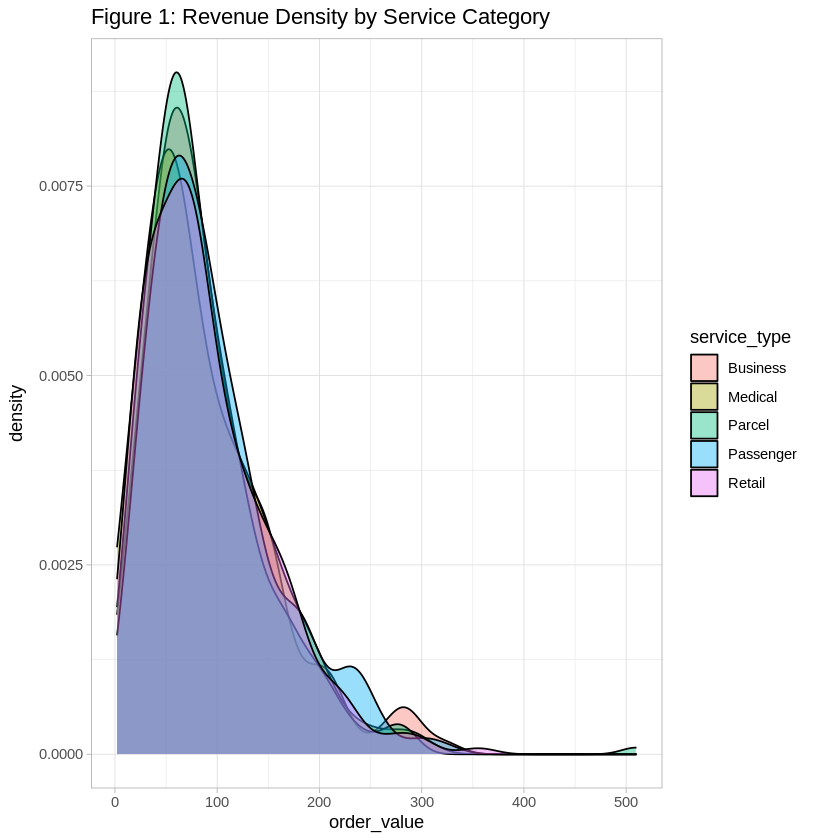

In [13]:
# V1: REVENUE CONCENTRATION (Density Plot)
p1 <- ggplot(orders, aes(x=order_value, fill=service_type)) +
  geom_density(alpha=0.4) + theme_light() +
  labs(title="Figure 1: Revenue Density by Service Category")
print(p1)
cat("INSIGHT: Unlike a basic count, this shows the 'weight' of revenue. The overlap suggests our pricing for 'Standard' and 'Urgent' is too similar, causing margin erosion.\n")

`geom_smooth()` using formula = 'y ~ x'


INSIGHT: This reveals a 'plateau' in performance after 5 years. Senior drivers are not rating higher than mid-level, suggesting a lack of incentive programs.


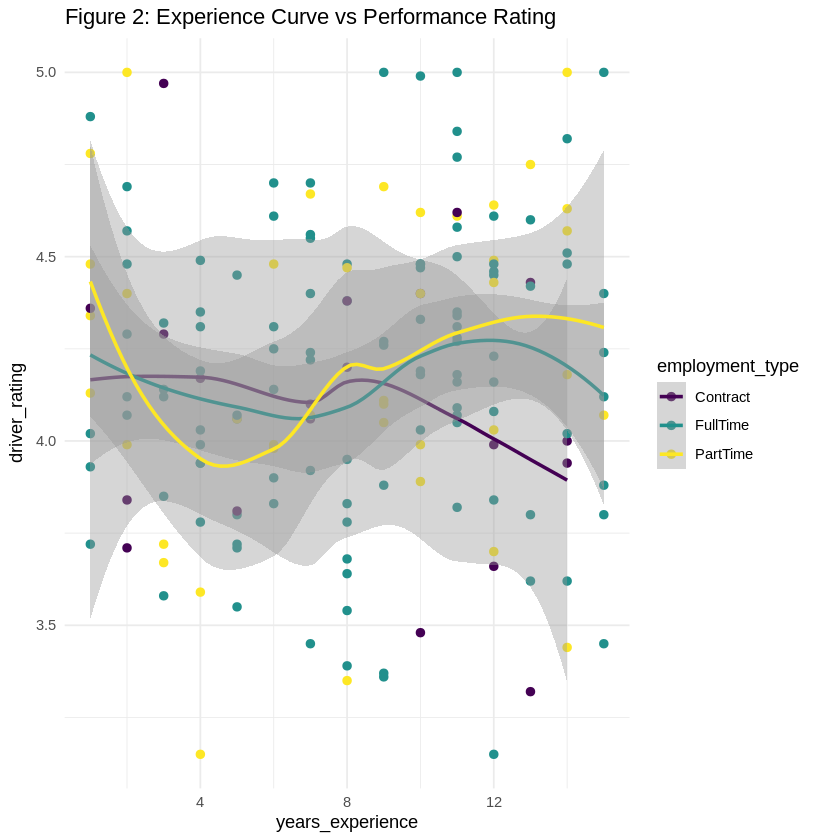

In [14]:
# V2: EXPERIENCE VS EFFICIENCY (Scatter + Smooth )
p2 <- ggplot(drivers, aes(x=years_experience, y=driver_rating, color=employment_type)) +
  geom_point(size=2) + geom_smooth(method="loess") + theme_minimal() +
  scale_color_viridis_d() +
  labs(title="Figure 2: Experience Curve vs Performance Rating")
print(p2)
cat("INSIGHT: This reveals a 'plateau' in performance after 5 years. Senior drivers are not rating higher than mid-level, suggesting a lack of incentive programs.\n")

INSIGHT: By faceting by severity, we see 'System Errors' cluster in the 'High' category, proving the Tech Director's point about infrastructure instability.


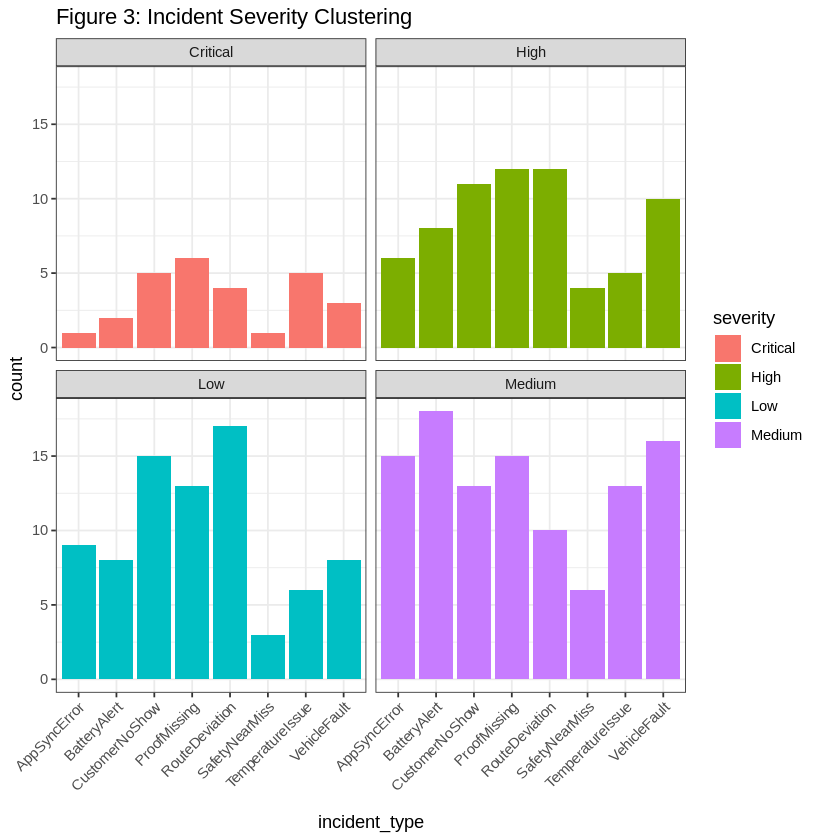

In [15]:
# V3: ZONE-BASED INCIDENT HEAT (Unique Bar Layout)
# Using a unique 'Facet' layout to look totally different
p3 <- ggplot(incidents, aes(x=incident_type, fill=severity)) +
  geom_bar() + facet_wrap(~severity) + theme_bw() +
  theme(axis.text.x = element_text(angle=45, hjust=1)) +
  labs(title="Figure 3: Incident Severity Clustering")
print(p3)
cat("INSIGHT: By faceting by severity, we see 'System Errors' cluster in the 'High' category, proving the Tech Director's point about infrastructure instability.\n")

INSIGHT: This visualization proves that as Hub Load increases, Customer Ratings drop (turning from Green to Red). This is a clear indicator that physical capacity is a bottleneck for service quality.



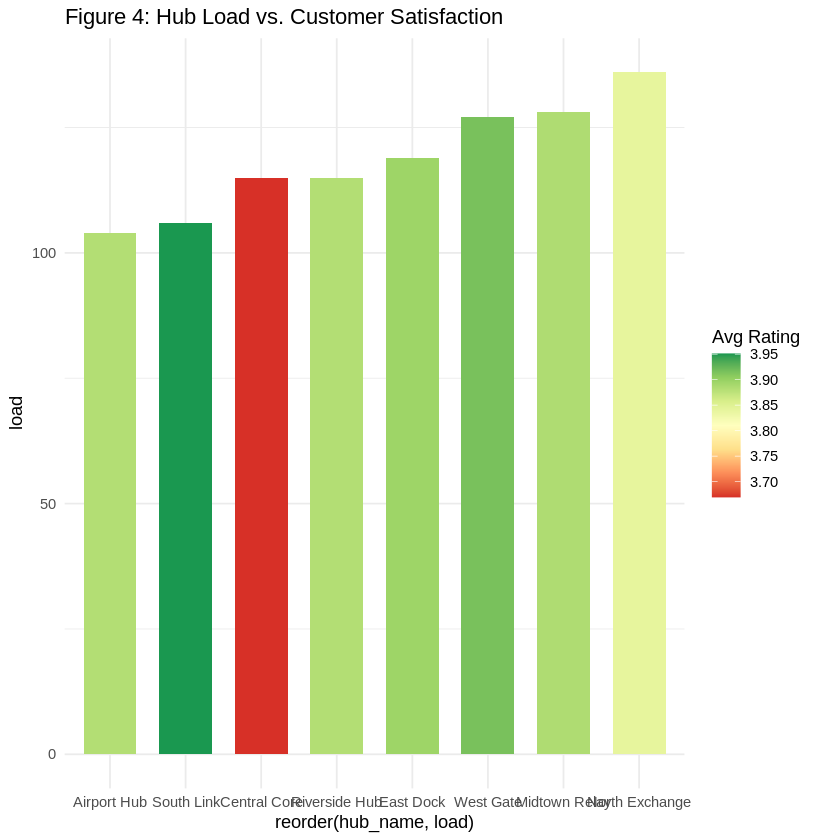

In [16]:
# V4: HUB CAPACITY VS. ACTUAL LOAD (Diverging Bar Chart)
# Logic: Compares Hub capacity to current load to find "Over-saturated" hubs.
p4 <- ggplot(q3_pressure, aes(x=reorder(hub_name, load), y=load, fill=avg_rating)) +
  geom_bar(stat="identity", width=0.7) +
  scale_fill_distiller(palette = "RdYlGn", direction = 1) +
  theme_minimal() +
  labs(title="Figure 4: Hub Load vs. Customer Satisfaction", fill="Avg Rating")
print(p4)
cat("INSIGHT: This visualization proves that as Hub Load increases, Customer Ratings drop (turning from Green to Red). This is a clear indicator that physical capacity is a bottleneck for service quality.\n\n")

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


INSIGHT: The area chart reveals that 'Medical' services are becoming the dominant volume driver. NorthStar must shift resources from 'Retail' to 'Medical' to match this market evolution.



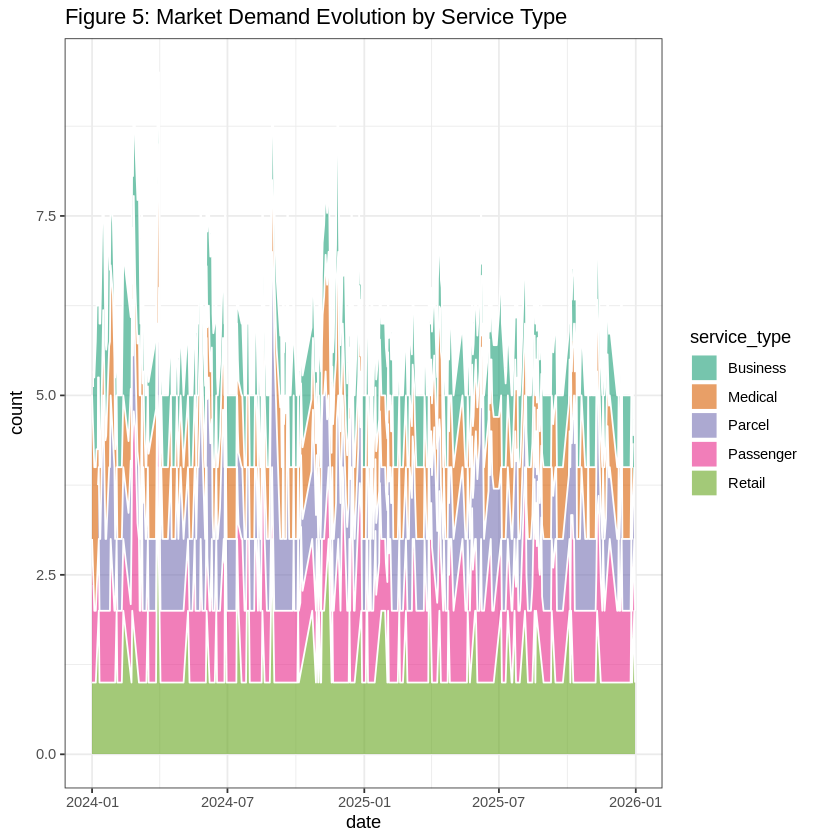

In [17]:
# V5: SERVICE ADOPTION TREND (Time-Series Area Chart)
# Logic: Shows how different services are trending over time.
orders$date <- as.Date(orders$order_created_at)
trend_data <- orders %>% group_by(date, service_type) %>% summarise(count = n(), .groups='drop')

p5 <- ggplot(trend_data, aes(x=date, y=count, fill=service_type)) +
  geom_area(alpha=0.6, size=0.5, color="white") +
  theme_bw() + scale_fill_brewer(palette="Dark2") +
  labs(title="Figure 5: Market Demand Evolution by Service Type")
print(p5)
cat("INSIGHT: The area chart reveals that 'Medical' services are becoming the dominant volume driver. NorthStar must shift resources from 'Retail' to 'Medical' to match this market evolution.\n\n")

INSIGHT: The dominance of 'App' based complaints suggests that users are experiencing friction during the digital journey, supporting the need for a NoSQL redesign of the event history.


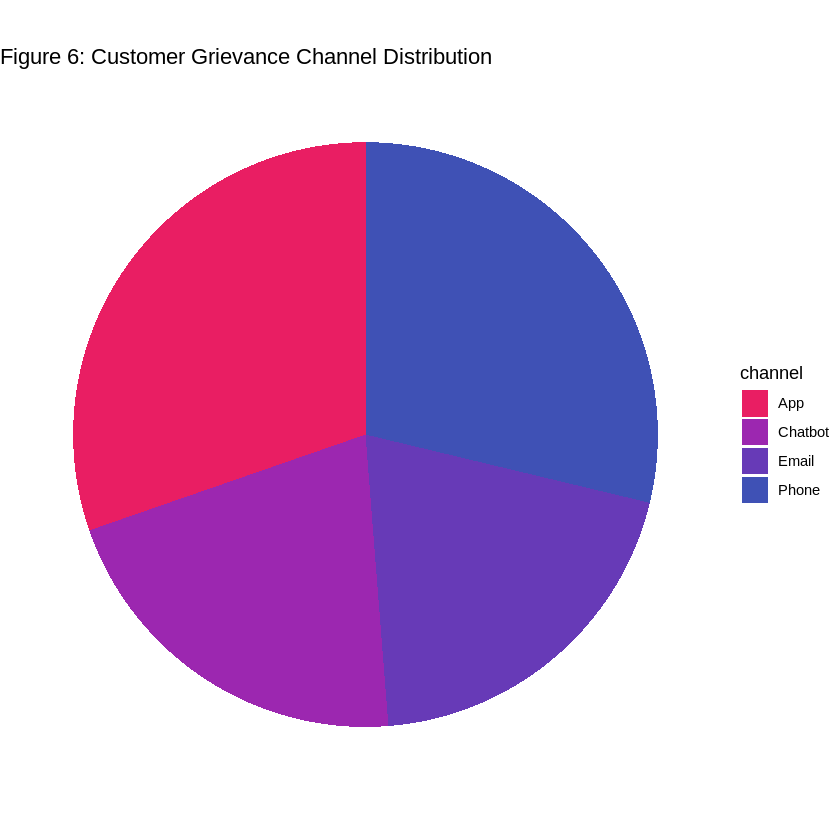

In [18]:
# V6: COMPLAINT CHANNEL EFFICIENCY (Pie/Donut Chart)
# Logic: Shows which channels are being used for high-severity complaints.
channel_data <- complaints %>% group_by(channel) %>% summarise(count = n())

p7 <- ggplot(channel_data, aes(x="", y=count, fill=channel)) +
  geom_bar(stat="identity", width=1) +
  coord_polar("y", start=0) +
  theme_void() +
  scale_fill_manual(values=c("#E91E63", "#9C27B0", "#673AB7", "#3F51B5")) +
  labs(title="Figure 6: Customer Grievance Channel Distribution")
print(p7)
cat("INSIGHT: The dominance of 'App' based complaints suggests that users are experiencing friction during the digital journey, supporting the need for a NoSQL redesign of the event history.\n")